# IMDb Sentiment Analysis with Transformers

A zero-shot baseline: `distilbert-base-uncased-finetuned-sst-2-english` applied
to real held-out IMDb reviews from Hugging Face Datasets, with no fine-tuning.
Useful as a ceiling to compare the TF-IDF model in `sentiment_analysis.ipynb`
against.

### Before you start

Transformer dependencies are heavy and are deliberately kept out of the base
install. Set them up **once, from your shell** — not from inside the notebook:

```bash
pip install -r requirements-transformers.txt
```

The previous version of this notebook ran `%pip install -t ./.pydeps_transformers`
at runtime and then purged `sys.modules` and patched `sys.path` to pick the
vendored copy up. That made results irreproducible (the notebook was never run
top to bottom — its execution counts ran 27 to 34) and is confusing to read.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoModelForSequenceClassification, AutoTokenizer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

C:\Users\thoma\IMDb_Sentiment_Analyzer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Pull real IMDb reviews from Hugging Face Datasets
imdb = load_dataset("imdb")
df = pd.DataFrame(imdb["test"])
df = df.sample(2000, random_state=RANDOM_STATE).reset_index(drop=True)
df = df.rename(columns={"text": "review"})
df["sentiment"] = df["label"].map({1: "positive", 0: "negative"})

print(f"Loaded {len(df)} real held-out IMDb reviews from test split.")
df.head()

Loaded 2000 real held-out IMDb reviews from test split.


,review,label,sentiment
0,I could not believe how terrible and boring th...,0,negative
1,I rented Boogie Nights last week and I could t...,1,positive
2,"First off, this movie is not near complete, my...",0,negative
3,I watched this mini in the early eighties. Sam...,1,positive
4,This movie was never intended as a big-budget ...,1,positive


In [3]:
# Load a pretrained sentiment model and tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, use_safetensors=True)
model.to(device)
model.eval()

print(f"Using device: {device}")

Using device: cpu


In [4]:
# Run batched inference for speed and stability
def predict_batch(batch_texts):
    enc = tokenizer(
        batch_texts,
        truncation=True,
        max_length=512,
        padding=True,
        return_tensors="pt"
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)
        scores, labels = torch.max(probs, dim=-1)
    return labels.cpu().numpy().tolist(), scores.cpu().numpy().tolist()

texts = df["review"].tolist()
predicted_labels = []
predicted_scores = []

for i in tqdm(range(0, len(texts), 32), desc="Inferring"):
    batch = texts[i:i+32]
    labels, scores = predict_batch(batch)
    predicted_labels.extend(labels)
    predicted_scores.extend(scores)

df["pred_label"] = predicted_labels
df["pred_score"] = predicted_scores

df[["review", "sentiment", "label", "pred_label", "pred_score"]].head()

Inferring:   0%|          | 0/63 [00:00<?, ?it/s]

Inferring:   2%|▏         | 1/63 [00:14<14:40, 14.20s/it]

Inferring:   3%|▎         | 2/63 [00:27<14:06, 13.87s/it]

Inferring:   5%|▍         | 3/63 [00:41<13:41, 13.68s/it]

Inferring:   6%|▋         | 4/63 [00:54<13:18, 13.53s/it]

...

Inferring:  97%|█████████▋| 61/63 [13:30<00:26, 13.09s/it]

Inferring:  98%|█████████▊| 62/63 [13:43<00:13, 13.11s/it]

Inferring: 100%|██████████| 63/63 [13:50<00:00, 11.17s/it]

Inferring: 100%|██████████| 63/63 [13:50<00:00, 13.18s/it]

,review,sentiment,label,pred_label,pred_score
0,I could not believe how terrible and boring th...,negative,0,0,0.999771
1,I rented Boogie Nights last week and I could t...,positive,1,1,0.995150
2,"First off, this movie is not near complete, my...",negative,0,0,0.999400
3,I watched this mini in the early eighties. Sam...,positive,1,1,0.993925
4,This movie was never intended as a big-budget ...,positive,1,1,0.988935


In [5]:
# Evaluate performance
y_true = df["label"]
y_pred = df["pred_label"]

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

Accuracy: 0.8910

              precision    recall  f1-score   support

    negative       0.88      0.91      0.90      1040
    positive       0.90      0.87      0.88       960

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



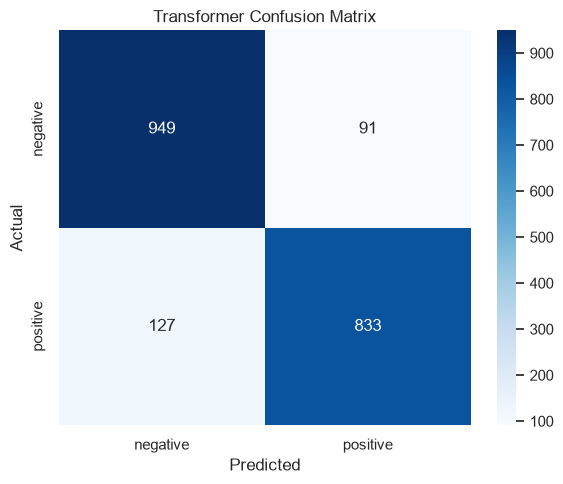

In [6]:
# Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [7]:
# Inspect predictions on real unseen reviews
sample_real = df.sample(5, random_state=RANDOM_STATE).copy()

for _, row in sample_real.iterrows():
    labels, scores = predict_batch([row["review"]])
    pred = "positive" if labels[0] == 1 else "negative"
    print(f"True: {row['sentiment']} | Pred: {pred} | Score: {scores[0]:.4f}")
    print(row["review"][:300].replace("\n", " ") + "...")
    print("-" * 100)

True: positive | Pred: positive | Score: 0.9794
The Elegant Universe brings to light many ideas of the universe and existence. After watching this documentary, one can't help but take a step back and rethink their view on the existence of everything. There is a large cast of scientists, mathematicians and others on both sides of String Theory. It...
----------------------------------------------------------------------------------------------------
True: negative | Pred: positive | Score: 0.9648
The recent release of "Mad Dog Morgan" on Troma DVD is disappointing.This appears to be a censored print for television viewing. Some of the more violent scenes have been edited and portions of the colorful language have been removed. Anyone who viewed the film uncut will be mad as hell at this toxi...
----------------------------------------------------------------------------------------------------


True: positive | Pred: negative | Score: 0.9676
After seeing the trailer it was an easy decision not to see this film. I mean, I don't care for stupid "stoner comedies." I'm sure it was also an easy choice for a lot of people to get together, smoke a bowl and go check out this flick with the guy from The Simpsons and some guy named "Billy Bob." S...
----------------------------------------------------------------------------------------------------


True: negative | Pred: negative | Score: 0.9996
The C class cast and poorly transitioned scenes, complete with terrible acting have led me too believe this would make a good TV only release such as the FX presentation of a smallpox outbreak. At my local blockbuster however, about 9 copies are held on the shelves, none of which were checked out wh...
----------------------------------------------------------------------------------------------------
True: negative | Pred: negative | Score: 0.9995
This "space snippet" was kind of dumb. I guess it was supposed to be a shocker unexpected ending, but IMHO it was just a huge letdown. Joseph Campanella and the rest of the earthbound actors do a great job in this one; their performances are not done justice with such a silly ending though. How this...
----------------------------------------------------------------------------------------------------
